# Batch conversion to MEI

**CAMAT workflow 1 of 3: editing music with the MEI data format — conversion.** See [Getting started](../docs/getting-started.md#choose-a-workflow) for the three workflows and `docs/guides/batch-conversion.md` for the companion guide.

The [single-source notebook](camat_formats.ipynb) explains the conversion routes. This notebook answers the corpus question: **how do we apply those routes to a source list, isolate failures, and retain an auditable report?**

All score examples come from `test_corpus/non_mei_test_copora_links.txt`. The notebook selects one Humdrum, one MusicXML, one MuseScore, and two MIDI URLs from that canonical manifest. The two MIDI sources deliberately share the basename `midi_score.mid` so the batch also proves that outputs remain distinct.

In [1]:
from pathlib import Path
from urllib.parse import urlparse
import json
import sys

import pandas as pd
from IPython.display import display

try:
    import setup_camat
except ModuleNotFoundError:
    pass
try:
    from camat.notebook_workspace import prepare_notebook
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "camat"])
    from camat.notebook_workspace import prepare_notebook

ROOT = prepare_notebook()

from camat import (
    DownloadOptions,
    MidiImportOptions,
    convert_sources,
    expand_file_sources,
    parse_files,
    set_validation_stage,
    vrv_display_svg,
    vrv_load_from_file,
    vrv_quiet,
    vrv_render_page,
    vrv_set_options,
)
from camat.conversion import print_conversion_summary

SOURCE_MANIFEST = ROOT / 'test_corpus' / 'non_mei_test_copora_links.txt'
OUTPUT_DIR = ROOT / 'converted_mei' / 'batch_conversion_tutorial'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repository:', ROOT)
print('Manifest:', SOURCE_MANIFEST)
print('Output:', OUTPUT_DIR)

Repository: /home/eggi/Nextcloud/code/public_repos/camat_v2
Manifest: /home/eggi/Nextcloud/code/public_repos/camat_v2/test_corpus/non_mei_test_copora_links.txt
Output: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial


## Expand one `.txt` manifest and select a mixed showcase

The manifest is a local text file with comments and raw URLs. `expand_file_sources(...)` returns the usable entries. A project-specific list may mix URLs and local paths; relative local paths resolve from `base_dir`.

The full test manifest is intentionally much larger than a tutorial run. We select named entries so the notebook covers different routes rather than merely taking the first three Humdrum files.

In [2]:
all_non_mei_sources = expand_file_sources(
    [str(SOURCE_MANIFEST)],
    base_dir=ROOT,
    verbose=True,
)

def select_source(fragment):
    return next(source for source in all_non_mei_sources if fragment in source)

showcase_specs = [
    {
        'format': 'Humdrum',
        'source': select_source('sonata14-1.krn'),
        'expected_route': 'verovio-direct',
    },
    {
        'format': 'MusicXML',
        'source': select_source('Schubert_D911-07.xml'),
        'expected_route': 'verovio-direct',
    },
    {
        'format': 'MuseScore',
        'source': select_source('Amazing_grace.mscz'),
        'expected_route': 'musescore-musicxml-verovio',
    },
    {
        'format': 'MIDI (Prelude)',
        'source': select_source('Bach/Prelude/bwv_846/midi_score.mid'),
        'expected_route': 'music21-musicxml-verovio',
    },
    {
        'format': 'MIDI (Fugue)',
        'source': select_source('Bach/Fugue/bwv_846/midi_score.mid'),
        'expected_route': 'music21-musicxml-verovio',
    },
]
SHOWCASE_SOURCES = [spec['source'] for spec in showcase_specs]
expected_route_by_source = {spec['source']: spec['expected_route'] for spec in showcase_specs}

print(f'Manifest entries: {len(all_non_mei_sources)}')
display(pd.DataFrame(showcase_specs))

Expanding sources from: /home/eggi/Nextcloud/code/public_repos/camat_v2/test_corpus/non_mei_test_copora_links.txt
  Added 56 source(s)
Manifest entries: 56


,format,source,expected_route
0,Humdrum,https://raw.githubusercontent.com/craigsapp/be...,verovio-direct
1,MusicXML,https://raw.githubusercontent.com/piasteuck/wi...,verovio-direct
2,MuseScore,https://raw.githubusercontent.com/musescore/Mu...,musescore-musicxml-verovio
3,MIDI (Prelude),https://raw.githubusercontent.com/fosfrancesco...,music21-musicxml-verovio
4,MIDI (Fugue),https://raw.githubusercontent.com/fosfrancesco...,music21-musicxml-verovio


## The batch conversion contract

`convert_sources(...)` is CAMAT's installed batch-conversion API. For each source it:

1. resolves or downloads the input to a local working copy;
2. identifies the route;
3. runs the final Verovio import in a child process so a native crash cannot kill the notebook kernel;
4. writes MEI to a source-unique filename without overwriting the source;
5. optionally renders page 1 as a smoke test;
6. returns a record containing route, output, intermediate file, SHA-256 provenance, MIDI voice-reconstruction counts, MEI counts, identifiers, and any error.

MuseScore sources need `mscore`, another MuseScore CLI name on `PATH`, or `MUSESCORE_BIN`. A missing executable should fail that record while the other sources continue.

In [3]:
TIMEOUT_SECONDS = 120
N_JOBS = 1
RENDER_FIRST_PAGE = True
MIDI_OPTIONS = MidiImportOptions()  # Override per corpus when 64ths or unusual tuplets are expected.
DOWNLOAD_OPTIONS = DownloadOptions(max_bytes=100 * 1024 * 1024)

records = convert_sources(
    SHOWCASE_SOURCES,
    output_dir=OUTPUT_DIR,
    timeout=TIMEOUT_SECONDS,
    render_first_page=RENDER_FIRST_PAGE,
    n_jobs=N_JOBS,
    show_progress=True,
    expand_txt_sources=False,
    source_base_dir=ROOT,
    midi_options=MIDI_OPTIONS,
    download_options=DOWNLOAD_OPTIONS,
    resume_policy='if-unchanged',
)

report_path = OUTPUT_DIR / 'conversion_report.json'
report_path.write_text(json.dumps(records, indent=2), encoding='utf-8')
print_conversion_summary(records)
print('Report:', report_path)

Converting with Verovio:   0%|          | 0/5 [00:00<?, ?file/s]


=== CAMAT Conversion Summary ===

status  input        pages measures   notes  xml:id  dupe  source
-----------------------------------------------------------------
ok      humdrum          4       69    1182    2487     0  https://raw.githubusercontent.com/craigsapp/beethoven-piano-sonatas/mas...
ok      musicxml         4       74    1341    4581     0  https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/h...
ok      musescore        1       17     175     897     0  https://raw.githubusercontent.com/musescore/MuseScore/main/demos/Amazin...
ok      midi             2       35     549    1605     0  https://raw.githubusercontent.com/fosfrancesco/asap-dataset/master/Bach...
ok      midi             2       27     783    2159     0  https://raw.githubusercontent.com/fosfrancesco/asap-dataset/master/Bach...

Output paths:
  skipped unchanged: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/batch_conversion_tutorial/sonata14-1_78ad2d5b8ae2_humdrum_verovio

## Read the report as a validation table

A record is ready for manual inspection when conversion succeeded through the expected route, an output MEI and checksum exist, rendering succeeded, notes were found, and no duplicate `xml:id` values were detected. These checks are a technical gate, not editorial certification.

In [4]:
def validation_status(record):
    if record.get('status') != 'ok':
        return 'route failed'
    expected_route = expected_route_by_source.get(record['source'])
    if expected_route and record.get('conversion_route') != expected_route:
        return 'unexpected route'
    if not record.get('output_mei'):
        return 'missing output'
    if not record.get('output_sha256'):
        return 'missing checksum'
    if RENDER_FIRST_PAGE and record.get('svg_ok') is not True:
        return 'render failed'
    if int(record.get('note_count') or 0) == 0:
        return 'no notes'
    if int(record.get('duplicate_xml_id_count') or 0) > 0:
        return 'duplicate xml:id'
    return 'ready for inspection'

report_rows = []
for record in records:
    source_path = Path(urlparse(record['source']).path)
    midi_diagnostics = record.get('music21_diagnostics') or {}
    report_rows.append({
        'source': '/'.join(source_path.parts[-3:]),
        'status': record.get('status'),
        'skipped': record.get('skipped'),
        'expected_route': expected_route_by_source.get(record['source']),
        'actual_route': record.get('conversion_route'),
        'source_sha256': (record.get('source_sha256') or '')[:12],
        'output_sha256': (record.get('output_sha256') or '')[:12],
        'resolved_url': record.get('resolved_url'),
        'tool_versions': record.get('tool_versions'),
        'conversion_seconds': record.get('conversion_duration_seconds'),
        'note_count': record.get('note_count'),
        'xml_id_count': record.get('xml_id_count'),
        'duplicate_xml_id_count': record.get('duplicate_xml_id_count'),
        'midi_quantization_grid': midi_diagnostics.get('quantization_quarter_length_divisors'),
        'midi_overlap_measures': midi_diagnostics.get('staggered_overlap_measures'),
        'midi_voice_measures_before': midi_diagnostics.get('voice_measures_before'),
        'midi_voice_measures_after': midi_diagnostics.get('voice_measures_after'),
        'midi_visible_rests_added': midi_diagnostics.get('visible_rests_added'),
        'validation': validation_status(record),
        'output_mei': record.get('output_mei'),
        'failure_stage': record.get('failure_stage'),
        'failure_code': record.get('failure_code'),
        'error': record.get('error'),
    })
report_df = pd.DataFrame(report_rows)
display(report_df)

,source,status,skipped,expected_route,actual_route,source_sha256,output_sha256,resolved_url,tool_versions,conversion_seconds,...,midi_quantization_grid,midi_overlap_measures,midi_voice_measures_before,midi_voice_measures_after,midi_visible_rests_added,validation,output_mei,failure_stage,failure_code,error
0,master/kern/sonata14-1.krn,ok,True,verovio-direct,verovio-direct,148db8c1d41c,930c0236750c,https://raw.githubusercontent.com/craigsapp/be...,"{'musescore': None, 'music21': None, 'verovio'...",0.050532,...,None,NaN,NaN,NaN,NaN,ready for inspection,/home/eggi/Nextcloud/code/public_repos/camat_v...,None,None,None
1,01_RawData/score_musicxml/Schubert_D911-07.xml,ok,True,verovio-direct,verovio-direct,0c744eed2a52,686d060733bf,https://raw.githubusercontent.com/piasteuck/wi...,"{'musescore': None, 'music21': None, 'verovio'...",0.001949,...,None,NaN,NaN,NaN,NaN,ready for inspection,/home/eggi/Nextcloud/code/public_repos/camat_v...,None,None,None
2,main/demos/Amazing_grace.mscz,ok,True,musescore-musicxml-verovio,musescore-musicxml-verovio,6a2546472e09,c2e1ed0ec1b2,https://raw.githubusercontent.com/musescore/Mu...,"{'musescore': 'MuseScore4 4.7.4', 'music21': N...",0.089290,...,None,NaN,NaN,NaN,NaN,ready for inspection,/home/eggi/Nextcloud/code/public_repos/camat_v...,None,None,None
3,Prelude/bwv_846/midi_score.mid,ok,True,music21-musicxml-verovio,music21-musicxml-verovio,3e2f8b9f3cf6,807c64b52745,https://raw.githubusercontent.com/fosfrancesco...,"{'musescore': None, 'music21': '10.5.0', 'vero...",0.001982,...,"[8, 6, 4, 3]",34.0,0.0,34.0,66.0,ready for inspection,/home/eggi/Nextcloud/code/public_repos/camat_v...,None,None,None
4,Fugue/bwv_846/midi_score.mid,ok,True,music21-musicxml-verovio,music21-musicxml-verovio,965a7e3fd012,3364aef8bd7e,https://raw.githubusercontent.com/fosfrancesco...,"{'musescore': None, 'music21': '10.5.0', 'vero...",0.004482,...,"[8, 6, 4, 3]",44.0,42.0,45.0,4.0,ready for inspection,/home/eggi/Nextcloud/code/public_repos/camat_v...,None,None,None


## Preview and parse the MIDI output

The report already renders every successful conversion. Here we display and parse the MIDI-derived MEI specifically, falling back to the first successful route only if MIDI failed. This verifies the music21 → MusicXML → MEI → DataFrame hand-off used by workflow 2.

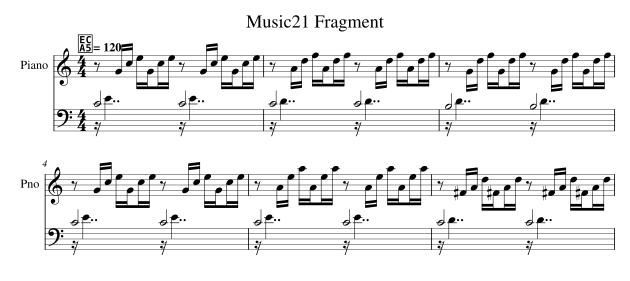

Processing (verovio): midi_score_896268229c29_midi_verovio.mei -> 00_midi_score_896268229c29_midi_verovio
Extracted non-barline MEI events: 42 event(s), types=['clef', 'key_sig', 'measure', 'meter_sig', 'tempo'].
Parsed: 00_midi_score_896268229c29_midi_verovio


,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.00,0.00,2.00,C4,60,P92e71c73fa88a6e4890d9779bb2612e4 - Voice 1,r6qaish,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2.00,<NA>
1,1,0.25,0.25,1.75,E4,64,P92e71c73fa88a6e4890d9779bb2612e4 - Voice 2,xrbcgde,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1.75,<NA>
2,1,0.50,0.50,0.25,G4,67,Piano - Voice 1,svk22n5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.25,<NA>
3,1,0.75,0.75,0.25,C5,72,Piano - Voice 1,u1c4lrvz,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.25,<NA>
4,1,1.00,1.00,0.25,E5,76,Piano - Voice 1,x1xja85r,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.25,<NA>


In [5]:
successful = [record for record in records if validation_status(record) == 'ready for inspection']
if not successful:
    print('No successful conversion to preview.')
else:
    preview_record = next(
        (record for record in successful if record.get('input_from') == 'midi'),
        successful[0],
    )
    preview_path = preview_record['output_mei']
    with vrv_quiet():
        vrv_set_options(pageWidth=2100, pageHeight=1200, scale=30, breaks='auto', removeIds=False)
        vrv_load_from_file(preview_path, input_from='mei')
        vrv_display_svg(vrv_render_page(1))

    parsed_results, _, parsed_df_pitch = parse_files(
        [preview_path],
        backend='none',
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        include_xml_ids=True,
        show_progress=False,
        quiet_native_warnings=True,
    )
    print('Parsed:', parsed_results[0]['name'])
    set_validation_stage(
        preview_record,
        'camat_parsed',
        'passed',
        f"{len(parsed_df_pitch)} combined df_pitch rows",
    )
    report_path.write_text(json.dumps(records, indent=2), encoding='utf-8')
    display(parsed_df_pitch.head())

## URLs, local paths, and `.txt` lists

The same helper accepts all three input forms:

```python
convert_sources(["https://example.org/score.krn"])
convert_sources(["path/to/local-score.musicxml"], source_base_dir=ROOT)
convert_sources(["path/to/source-list.txt"], source_base_dir=ROOT)
```

The source-list form expands comments, URLs, and relative local paths. To run the complete canonical conversion corpus from the command line:

```bash
camat-convert \
  --source test_corpus/non_mei_test_copora_links.txt \
  --n-jobs 1
```

A smaller URL-only text-list example remains at `notebooks/data/batch_sources.txt`.

## What this notebook produced

- a deliberately mixed selection expanded from the canonical corpus manifest;
- isolated conversion records for Humdrum, MusicXML, MuseScore, and two same-basename MIDI sources;
- converted MEI plus downloaded and intermediate working files under `converted_mei/batch_conversion_tutorial/`;
- `conversion_report.json` and a validation table;
- a render and parsing smoke test for one successful result.

Continue with workflow 2, `docs/guides/parsing-representations.md`, to work directly with `df_pitch` and `df_events`.